In [58]:
# %pip install -q pandas numpy rank-bm25 python-dotenv requests
# (Optional for embeddings)
# %pip install -q sentence-transformers faiss-cpu

from __future__ import annotations
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple
import random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from IPython.display import display, Markdown

load_dotenv()  # reads ANTHROPIC_API_KEY from .env

random.seed(7); np.random.seed(7)

In [59]:
DATA_DIR = Path("data")

#### Load Data

In [60]:
act_df = pd.read_csv(Path(DATA_DIR, 'activities.csv'))
print(act_df.head(5))

      id           city                            name   theme  \
0  A0001  New York City                    Central Park  sports   
1  A0002  New York City  The Metropolitan Museum of Art  family   
2  A0003  New York City                    Times Square   beach   
3  A0004  New York City               Statue of Liberty   music   
4  A0005  New York City                 Brooklyn Bridge  sports   

   duration_hours  cost_usd opening_hours                  notes  
0             1.0        40   08:00-20:00  Accessible by transit  
1             2.6        30   10:00-17:00      Great photo spots  
2             3.0        40   08:00-19:00             Book ahead  
3             3.1        20   08:00-17:00         Local favorite  
4             1.2        40   08:00-19:00         Local favorite  


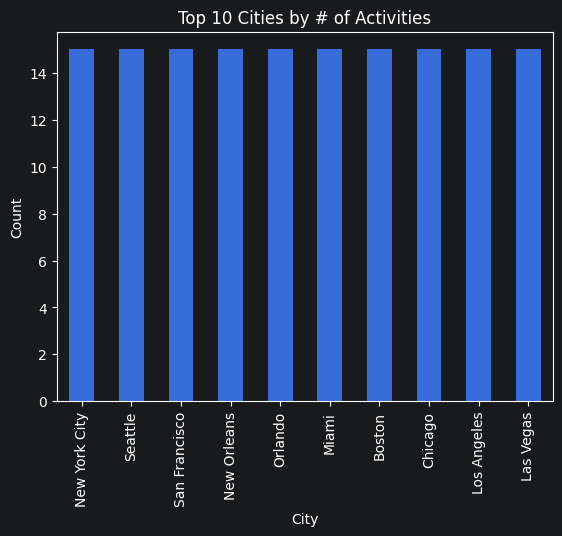

In [61]:
# Activities by city
city_counts = act_df["city"].value_counts().sort_values(ascending=False).head(10)
plt.figure()
city_counts.plot(kind="bar")
plt.title("Top 10 Cities by # of Activities")
plt.xlabel("City"); plt.ylabel("Count")
plt.show()

In [62]:
hotel_df = pd.read_csv(Path(DATA_DIR, 'hotels.csv'))
print(hotel_df.head(5))

      id           city                     name       neighborhood  \
0  H0001  New York City                The Plaza  Historic District   
1  H0002  New York City  The Standard, High Line         Waterfront   
2  H0003  New York City    The Langham, New York      Arts District   
3  H0004  New York City               The Pierre         Waterfront   
4  H0005  New York City         The Bowery Hotel       Near Transit   

   nightly_price_usd  review_score  walk_score             notes  
0                263           4.0          86  Close to transit  
1                146           3.8          86   Great nightlife  
2                123           3.8          77    Good breakfast  
3                285           4.1          69      Near museums  
4                117           4.0          80    Good breakfast  


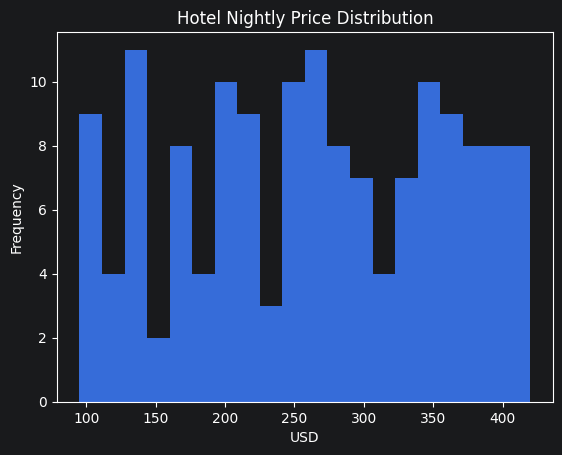

In [63]:
plt.figure()
hotel_df["nightly_price_usd"].plot(kind="hist", bins=20)
plt.title("Hotel Nightly Price Distribution")
plt.xlabel("USD"); plt.ylabel("Frequency")
plt.show()


In [64]:
flight_df = pd.read_csv(Path(DATA_DIR, 'flights.csv'))
print(flight_df.head(5))

      id         origin    destination   airline  price_usd depart_time  \
0  F0001  San Francisco   Philadelphia    Alaska        223       10:45   
1  F0002       Portland  San Francisco    Spirit        601       16:10   
2  F0003         Austin         Denver  American        398       12:30   
3  F0004         Boston  San Francisco    Alaska        162       12:30   
4  F0005         Denver       Portland     Delta        397       18:25   

  arrive_time  on_time_rate  
0       10:43          0.84  
1       12:45          0.78  
2       14:10          0.93  
3       12:45          0.85  
4       08:55          0.80  


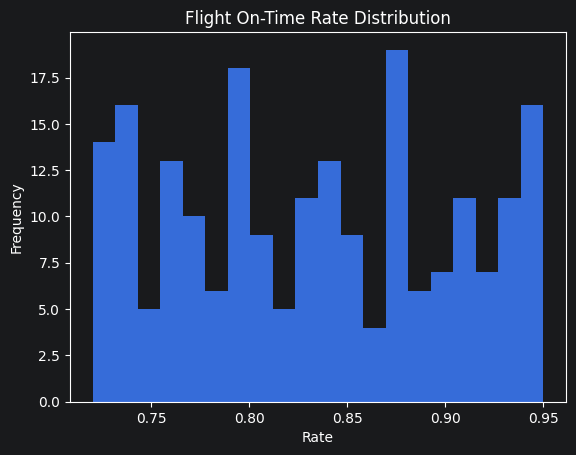

In [65]:
plt.figure()
flight_df["on_time_rate"].plot(kind="hist", bins=20)
plt.title("Flight On-Time Rate Distribution")
plt.xlabel("Rate"); plt.ylabel("Frequency")
plt.show()

#### How to use Claude API

In [66]:
def logged_create(**kwargs):
    print("=== INPUT ===")
    if "system" in kwargs:
        print(f"[system]: {kwargs['system']}\n")
    for msg in kwargs.get("messages", []):
        print(f"[{msg['role']}]: {msg['content']}\n")
    print("=============")

    response = client.messages.create(**kwargs)

    print("=== OUTPUT ===")
    print(response.content[0].text)
    print("==============\n")

    return response

In [67]:
import anthropic
client = anthropic.Anthropic()

system_prompt = "Being an expert in trip planning, write clear travel recommendations."
messages = []

def chat(user_input: str) -> str:
    messages.append({"role": "user", "content": user_input})
    response = logged_create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        system=system_prompt,
        messages=messages,
        temperature=0.2
    )
    reply = response.content[0].text
    messages.append({"role": "assistant", "content": reply})
    return reply

print(chat("I need a 5 day travel plan from San Francisco to Los Angeles."))
print(chat("What about budget options for accommodation?"))  # Claude remembers the prior turn


=== INPUT ===
[system]: Being an expert in trip planning, write clear travel recommendations.

[user]: I need a 5 day travel plan from San Francisco to Los Angeles.

=== OUTPUT ===
# 5-Day San Francisco to Los Angeles Road Trip Plan

## Overview
This scenic road trip covers approximately **400 miles** along the stunning California coast, combining breathtaking views, charming towns, and iconic landmarks.

---

## Day 1: San Francisco → Monterey (~120 miles)
**Drive Time:** ~2 hours

### Highlights
- **Morning:** Explore **Fisherman's Wharf** and grab a sourdough bread bowl before departing
- **Afternoon:** Stop at **Santa Cruz** — walk the famous boardwalk and pier
- **Evening:** Arrive in **Monterey** — stroll Cannery Row and enjoy fresh seafood dinner

### Stay
🏨 **Recommended:** Portola Hotel & Spa, Monterey

---

## Day 2: Monterey → Big Sur (~30 miles)
**Drive Time:** ~1 hour

### Highlights
- **Morning:** Visit the world-class **Monterey Bay Aquarium**
- **Afternoon:** Drive thro

Logging my request as Claude does not support viewing input

#### RAG — Step 1: BM25 Keyword Retrieval

In [68]:
from rank_bm25 import BM25Okapi

# --- Step 1: Serialize each row into a text document ---
# Each doc is a plain string of all field values; we keep a parallel list of
# the original row dicts so we can return structured data after retrieval.

def build_corpus(dataframes: dict) -> tuple[list[str], list[dict]]:
    docs, metadata = [], []
    for source, df in dataframes.items():
        for _, row in df.iterrows():
            # Meta data injection so that each doc string knows its label
            # ex: flight query should be highly related to flight csv table data
            # but too much semantic injection will cause data to get messy, use embedding then
            text = f"{source} " + " ".join(str(value) for value in row.values).lower()

            docs.append(text)

            # TODO2: store the source name + row data as a dict in metadata
            row_dict = row.to_dict()
            row_dict["source"] = source
            row_dict["text"] = text
            metadata.append(row_dict)

    return docs, metadata


dataframes = {"activities": act_df, "hotels": hotel_df, "flights": flight_df}
corpus_docs, corpus_meta = build_corpus(dataframes)
#print(corpus_docs)
#(corpus_meta)


In [69]:
# --- Step 2: Build BM25 index ---
tokenized_corpus = [doc.split() for doc in corpus_docs]
bm25 = BM25Okapi(tokenized_corpus)

print(f"Index built: {len(corpus_docs)} documents")

Index built: 585 documents


In [70]:
import re

# --- Tokenizer strategies ---
def tokenize_simple(text):
    """Basic whitespace split — mirrors build_corpus"""
    return text.lower().split()

def tokenize_clean(text):
    """Strip punctuation before splitting — symbols become spaces"""
    return re.sub(r"[^a-z0-9\s]", " ", text.lower()).split()


# --- Text builder strategies (how a row becomes a document) ---
def text_all_fields(source, row):
    """Index every field — current default"""
    return " ".join(str(v) for v in row.values)

def text_selective(source, row):
    """Only index meaningful text fields — drop numeric/time fields"""
    if source == "activities":
        return f"{row['name']} {row['city']} {row['theme']} {row['notes']}"
    elif source == "hotels":
        return f"{row['name']} {row['city']} {row['neighborhood']} {row['notes']}"
    elif source == "flights":
        return f"{row['origin']} {row['destination']} {row['airline']}"

def text_weighted(source, row):
    """Repeat key fields to boost their BM25 term frequency"""
    if source == "activities":
        return f"{row['name']} {row['name']} {row['city']} {row['theme']} {row['theme']} {row['notes']}"
    elif source == "hotels":
        return f"{row['name']} {row['name']} {row['city']} {row['neighborhood']} {row['notes']}"
    elif source == "flights":
        return f"{row['origin']} {row['origin']} {row['destination']} {row['airline']}"


# --- Strategy presets: (text_builder, tokenizer) ---
STRATEGIES = {
    "default":   (text_all_fields, tokenize_simple),   # original behaviour
    "clean":     (text_all_fields, tokenize_clean),    # strip symbols
    "selective": (text_selective,  tokenize_simple),   # text fields only
    "weighted":  (text_weighted,   tokenize_simple),   # boost key fields
}


# --- Generic index builder ---
def build_index(dataframes, text_fn, tokenize_fn):
    docs, metadata = [], []
    for source, df in dataframes.items():
        for _, row in df.iterrows():
            text = text_fn(source, row).lower()
            tokens = tokenize_fn(text)
            docs.append(tokens)
            row_dict = row.to_dict()
            row_dict["source"] = source
            metadata.append(row_dict)
    return BM25Okapi(docs), metadata


# --- Generic retrieve ---
def retrieve(query, bm25_index, corpus_meta, tokenize_fn=tokenize_simple, top_k=5):
    tokens = tokenize_fn(query)
    scores = bm25_index.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [corpus_meta[i] for i in top_indices if scores[i] > 0]


# --- Compare all strategies side by side ---
def compare_strategies(query, top_k=5):
    print(f'Query: "{query}"\n')
    for name, (text_fn, tok_fn) in STRATEGIES.items():
        bm25_idx, meta = build_index(dataframes, text_fn, tok_fn)
        results = retrieve(query, bm25_idx, meta, tok_fn, top_k)
        print(f"  [{name}]")
        if not results:
            print("    (no matches)")
        for r in results:
            label = r.get("name") or f"{r.get('origin')} → {r.get('destination')}"
            print(f"    [{r['source']}] {label}")
        print()


In [71]:
# --- Try different queries to see how strategies differ ---
compare_strategies("outdoor sports activities new york")
compare_strategies("cheap flights from San Francisco") #weighted for origin based flight queries
compare_strategies("08:00")   # interesting: clean is only one matched the time with pure number
compare_strategies("San Francisco at 08:00")


Query: "outdoor sports activities new york"

  [default]
    [activities] Brooklyn Bridge
    [activities] Central Park
    [activities] Grand Central Terminal
    [hotels] The Peninsula New York
    [hotels] The Langham, New York

  [clean]
    [activities] Brooklyn Bridge
    [activities] Central Park
    [activities] Grand Central Terminal
    [hotels] The Peninsula New York
    [hotels] The Langham, New York

  [selective]
    [activities] Brooklyn Bridge
    [activities] Central Park
    [activities] Grand Central Terminal
    [hotels] The Peninsula New York
    [flights] New York City → New Orleans

  [weighted]
    [activities] Brooklyn Bridge
    [activities] Central Park
    [activities] Grand Central Terminal
    [flights] New York City → New Orleans
    [flights] New York City → Orlando

Query: "cheap flights from San Francisco"

  [default]
    [hotels] Fairmont San Francisco
    [flights] San Francisco → San Diego
    [flights] San Diego → San Francisco
    [flights] San F

In [72]:
# --- Step 4: Format retrieved results as a context string for Claude ---

def format_context(results: list[dict]) -> str:
    lines = []
    for r in results:
        source = r["source"]
        # exclude internal keys that aren't useful context for the model
        fields = {k: v for k, v in r.items() if k not in ("source", "text")}
        field_string = [f"{key}: {value}" for key, value in fields.items()]
        lines.append(f"[{source.upper()}] {' | '.join(field_string)}")
    return "\n".join(lines)

In [73]:
# --- Step 5: RAG-augmented chat ---

default_bm25, default_meta = build_index(dataframes, text_all_fields, tokenize_simple)

rag_messages = []

def rag_chat(user_input: str, top_k: int = 5) -> str:
    results = retrieve(user_input, default_bm25, default_meta, tokenize_simple, top_k)
    context = format_context(results)

    content = (
        "Use the retrieved data below to answer the question.\n\n"
        f"Data:\n{context}\n\n"
        f"Question: {user_input}"
    )

    rag_messages.append({"role": "user", "content": content})
    response = logged_create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        system=system_prompt,
        messages=rag_messages,
        temperature=0.2
    )
    reply = response.content[0].text
    rag_messages.append({"role": "assistant", "content": reply})
    return reply


#### RAG Chat Queries

In [74]:
# --- Single-turn queries ---
rag_messages.clear()

rag_chat("What are some sports activities in New York City?")
rag_chat("Find me a cheap flight from San Francisco to Los Angeles.")
rag_chat("What are the best rated hotels in Chicago?")

# --- Multi-turn: follow-up uses prior context ---
rag_messages.clear()

rag_chat("I want to visit New York City for outdoor activities.")
rag_chat("What hotels are nearby?")  # Claude remembers New York City, \
                                    # but BM25 does not know previous queries


=== INPUT ===
[system]: Being an expert in trip planning, write clear travel recommendations.

[user]: Use the retrieved data below to answer the question.

Data:
[ACTIVITIES] id: A0005 | city: New York City | name: Brooklyn Bridge | theme: sports | duration_hours: 1.2 | cost_usd: 40 | opening_hours: 08:00-19:00 | notes: Local favorite
[ACTIVITIES] id: A0001 | city: New York City | name: Central Park | theme: sports | duration_hours: 1.0 | cost_usd: 40 | opening_hours: 08:00-20:00 | notes: Accessible by transit
[ACTIVITIES] id: A0009 | city: New York City | name: Grand Central Terminal | theme: sports | duration_hours: 3.1 | cost_usd: 65 | opening_hours: 11:00-21:00 | notes: Good for groups
[HOTELS] id: H0006 | city: New York City | name: The Peninsula New York | neighborhood: Waterfront | nightly_price_usd: 256 | review_score: 4.7 | walk_score: 82 | notes: Good breakfast
[HOTELS] id: H0118 | city: Denver | name: Halcyon, a hotel in Cherry Creek | neighborhood: Near Park | nightly_pric

'# Hotel Recommendations\n\nI\'m sorry, but **no data was retrieved** to answer your question about nearby hotels. This could be because:\n\n- 📍 **No location was specified** — I\'m not sure which area or city you\'re referring to\n- 🔍 **No matching results** were found in the database for your query\n\n---\n\n## 💡 How I Can Help\n\nTo find the best hotel recommendations for you, try asking something like:\n\n- *"What hotels are available in **New York City**?"*\n- *"Find me hotels near **Central Park**"*\n- *"What are the best budget hotels in **Chicago**?"*\n\nPlease refine your question with a **specific location** and I\'ll do my best to provide tailored recommendations! 🏨'

## Next Plan: Retrieval Strategy Comparison

### Goal
Compare three retrieval strategies side by side to understand their trade-offs:

| Strategy | Approach | Strength | Weakness |
|---|---|---|---|
| **BM25** ✅ done | Term frequency + IDF scoring | Fast, no model needed | Exact token match only — `"cheap"` never matches `cost_usd: 40` |
| **Exact Keyword Match** ← next | `in` substring search | Handles partial matches e.g. `"08:00"` matches `"08:00-20:00"` | No ranking, no semantics |
| **Embeddings** | Semantic vector similarity | Understands meaning — `"cheap"` can match low `cost_usd` | Slower, needs a model |

---

### Next Step: Exact Keyword Match

Implement `retrieve_exact(query, corpus_meta, top_k)` that:
1. Splits query into individual keywords (lowercased)
2. For each doc in `corpus_meta`, counts how many keywords appear as **substrings** in the doc text
3. Ranks results by hit count (most matches first), returns top_k in the same `list[dict]` format as `retrieve()`

Then add `compare_retrieval(query)` that runs BM25 and exact keyword match on the same query side by side.

### Key questions to answer
- Does exact match fix the `"08:00"` vs `"08:00-20:00"` problem BM25 had with the `default` strategy?
- Does substring matching cause false positives (e.g. `"or"` matching `"New York"`)?
- Does it return more or fewer results than BM25 for the same query?

### Shared infrastructure already in place
- `corpus_meta` — list of row dicts with `"source"` key (reuse directly)
- `build_corpus()` — provides `corpus_docs` with the lowercased text strings (reuse as the search corpus)
- `format_context()` — formats results for Claude (no changes needed)
- `rag_chat()` — plugs in any retrieval function that returns `list[dict]`
- `logged_create()` — logs all Claude API calls automatically


#### RAG — Step 2: Exact Keyword Match

In [79]:
# --- Step: Exact Keyword Match Retrieval ---
def retrieve_exact(query: str, corpus_docs: list[str], corpus_meta: list[dict], top_k: int = 5) -> list[dict]:
    """
    Substring match: count how many query keywords appear anywhere in the doc text.
    Fixes BM25's problem with partial strings like '08:00' inside '08:00-20:00'.
    Risk: short keywords like 'or' can match inside any word (false positives).
    """

    keywords = query.lower().split()
    #need to escape word boundary so that keyword like "or" does not match y"or"k
    scores = [sum(1 for kw in keywords if bool(re.search(rf"\b{re.escape(kw)}\b", doc))) for doc in corpus_docs]
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = [corpus_meta[i] for i in top_indices if scores[i] > 0]
    return results if results else []

In [80]:
# --- Compare BM25 vs Exact Keyword side by side ---
def compare_retrieval(query: str, top_k: int = 5):
    print(f'Query: "{query}"\n')

    bm25_results = retrieve(query, default_bm25, default_meta, tokenize_simple, top_k)
    print("  [BM25]")
    if not bm25_results:
        print("    (no matches)")
    for r in bm25_results:
        label = r.get("name") or f"{r.get('origin')} → {r.get('destination')}"
        print(f"    [{r['source']}] {label}")

    exact_results = retrieve_exact(query, corpus_docs, corpus_meta, top_k)
    print("\n  [Exact Keyword]")
    if not exact_results:
        print("    (no matches)")
    for r in exact_results:
        label = r.get("name") or f"{r.get('origin')} → {r.get('destination')}"
        print(f"    [{r['source']}] {label}")
    print()

In [81]:
# --- Test queries: answer the key questions ---
compare_retrieval("08:00")                           # BM25 none found, Exact found several starting at 8
compare_retrieval("or")                              # exact match caused or in new y"or"k to show up
compare_retrieval("outdoor sports activities new york")
compare_retrieval("cheap flights from San Francisco") #cheap sematically not understood by both

Query: "08:00"

  [BM25]
    (no matches)

  [Exact Keyword]
    [activities] Space Needle
    [activities] Pike Place Market
    [activities] Central Park
    [activities] Mission Beach Boardwalk
    [activities] Old Town San Diego State Historic Park

Query: "or"

  [BM25]
    (no matches)

  [Exact Keyword]
    (no matches)

Query: "outdoor sports activities new york"

  [BM25]
    [activities] Brooklyn Bridge
    [activities] Central Park
    [activities] Grand Central Terminal
    [hotels] The Peninsula New York
    [hotels] The Langham, New York

  [Exact Keyword]
    [activities] Central Park
    [activities] Grand Central Terminal
    [activities] Brooklyn Bridge
    [activities] Jackson Square
    [activities] 9/11 Memorial & Museum

Query: "cheap flights from San Francisco"

  [BM25]
    [hotels] Fairmont San Francisco
    [flights] San Francisco → San Diego
    [flights] San Diego → San Francisco
    [flights] San Francisco → Philadelphia
    [flights] Philadelphia → San Fra

## Next Plan: Embedding-Based Retrieval

| Step | What |
|---|---|
| 1 | Load `sentence-transformers` model (`all-MiniLM-L6-v2`) and encode all docs |
| 2 | Build a FAISS index from the doc embeddings |
| 3 | Implement `retrieve_semantic(query, top_k)` using cosine similarity |
| 4 | Extend `compare_retrieval()` to show a third column: `[Semantic]` |

**Key question:** does `"cheap"` now match low `cost_usd` values that BM25 and exact both miss?

#### Step 2a: Stemming / Lemmatization

Exact keyword match treats `"sports"` and `"sporting"` as completely different strings. They won't match.

**Stemming** reduces words to their root form *before* indexing and querying:
- `"sporting"` → `"sport"`, `"running"` → `"run"`, `"activities"` → `"activ"`

Critical rule: **both the query and the docs must be stemmed the same way.** If the doc is stemmed but the query isn't (or vice versa), nothing matches.

Libraries:
- `nltk` PorterStemmer — fast, aggressive, English-only
- `spacy` lemmatizer — slower, more linguistically accurate (understands grammar context)

In [82]:
# pip install nltk
import nltk
from nltk.stem import PorterStemmer

# nltk.download('punkt')  # uncomment if you get a resource error
stemmer = PorterStemmer()

def stem_tokens(tokens: list[str]) -> list[str]:
    stemmer_list = [stemmer.stem(token) for token in tokens]
    return stemmer_list

def build_stemmed_corpus(corpus_docs: list[str]) -> list[str]:
    """
    Pre-stem every doc so the query and docs are compared in the same reduced form.
    Both sides MUST use the same stemmer — stemming only works if it's symmetric.
    """
    stemmed_corpus = []
    for doc in corpus_docs:
        tokens = doc.split()
        stemmed_tokens = stem_tokens(tokens)
        stemmed_corpus.append(" ".join(stemmed_tokens))
    return stemmed_corpus

def retrieve_stemmed(query: str, stemmed_docs: list[str],
                     corpus_meta: list[dict], top_k: int = 5) -> list[dict]:
    query_tokens = stem_tokens(query.lower().split())
    scores = [sum(1 for kw in query_tokens if kw in doc) for doc in stemmed_docs]
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [corpus_meta[i] for i in top_indices if scores[i] > 0]

In [83]:
# "sporting activities" should now match docs containing "sports" ---
stemmed_corpus = build_stemmed_corpus(corpus_docs)
retrieve_exact("sporting", corpus_docs, corpus_meta)    # no result
retrieve_stemmed("sporting", stemmed_corpus, corpus_meta)  # 5 hit

[{'id': 'A0001',
  'city': 'New York City',
  'name': 'Central Park',
  'theme': 'sports',
  'duration_hours': 1.0,
  'cost_usd': 40,
  'opening_hours': '08:00-20:00',
  'notes': 'Accessible by transit',
  'source': 'activities',
  'text': 'activities a0001 new york city central park sports 1.0 40 08:00-20:00 accessible by transit'},
 {'id': 'A0225',
  'city': 'San Diego',
  'name': 'Little Italy',
  'theme': 'sports',
  'duration_hours': 2.7,
  'cost_usd': 15,
  'opening_hours': '10:00-21:00',
  'notes': 'Popular with students',
  'source': 'activities',
  'text': 'activities a0225 san diego little italy sports 2.7 15 10:00-21:00 popular with students'},
 {'id': 'A0215',
  'city': 'San Diego',
  'name': 'Coronado Beach',
  'theme': 'sports',
  'duration_hours': 1.5,
  'cost_usd': 120,
  'opening_hours': '10:00-18:00',
  'notes': 'Family friendly',
  'source': 'activities',
  'text': 'activities a0215 san diego coronado beach sports 1.5 120 10:00-18:00 family friendly'},
 {'id': 'A0212

#### Step 2b: Inverted Index

`retrieve_exact()` scans every doc for every keyword — O(docs × keywords). Fine for hundreds of rows, unusable for millions.

An **inverted index** flips the lookup:
- **Build once**: `word → [doc_id, doc_id, ...]`
- **Query**: look up each keyword → get candidate doc sets → count overlaps → rank

This is the data structure inside Elasticsearch, Lucene, and every production search engine. BM25 is also built on top of an inverted index — understanding this makes the rest of search click.

In [95]:
from collections import defaultdict

def build_inverted_index(corpus_docs: list[str]) -> dict[str, list[int]]:
    """
    Build once, query fast.
    Maps each unique token → list of doc indices that contain it.
    Example: {"sports": [0, 4, 17], "york": [0, 1, 2, 5], ...}

    Using a set of tokens per doc means each token is recorded at most once per doc
    (same behaviour as exact match — presence, not frequency).
    """
    index = defaultdict(list)
    for doc_id, doc in enumerate(corpus_docs):
        unique_tokens = set(doc.split())
        for token in unique_tokens:
            index[token].append(doc_id)
    return dict(index)

def retrieve_inverted(query: str, index: dict[str, list[int]],
                      corpus_meta: list[dict], top_k: int = 5) -> list[dict]:
    """
    Score = number of query keywords found in the index for each doc.
    No doc scanning — just dict lookups.
    """
    keywords = query.lower().split()
    scores = np.zeros(len(corpus_meta))
    for kw in keywords:
        for doc_id in index.get(kw, []):
            scores[doc_id] += 1
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [corpus_meta[i] for i in top_indices if scores[i] > 0]


In [ ]:
# --- Test: should return same results as retrieve_exact but much faster at scale ---
inv_index = build_inverted_index(corpus_docs)
retrieve_inverted("sports new york", inv_index, corpus_meta)

#### Step 2c: Precision & Recall — Evaluating Retrieval Quality

Without metrics, you're eyeballing results. Precision and Recall let you *measure* how good each method is objectively.

| Metric | Question it answers | Formula |
|---|---|---|
| **Precision@k** | Of the k results I returned, how many were actually relevant? | relevant_in_top_k / k |
| **Recall@k** | Of all relevant docs that exist, how many did I find? | relevant_in_top_k / total_relevant |

You need **ground truth** — a manually labelled set of `(query → relevant doc indices)`.
Once you have it, you can compare BM25 vs exact vs embeddings with a real number instead of a gut feeling.

In [ ]:
corpus_meta[0]

In [96]:
# Ground truth: (query → set of relevant doc indices in corpus_meta)
# Cheap flights defined as SF origin/destination with price_usd <= 300
GROUND_TRUTH: dict[str, set[int]] = {
    "sports activities new york": {0, 4, 8},
    "cheap flights san francisco": {375, 378, 380, 381, 545, 548, 564, 578},
}

id_to_index = {meta["id"]: i for i, meta in enumerate(corpus_meta)}

def precision_at_k(retrieved: list[dict], relevant_ids: set[int],
                   corpus_meta: list[dict], k: int = 5) -> float:
    """Of the top-k results returned, what fraction were actually relevant?"""
    top_k = retrieved[:k]
    count = sum(1 for doc in top_k if id_to_index.get(doc["id"]) in relevant_ids)
    return count / k if k > 0 else 0.0

def recall_at_k(retrieved: list[dict], relevant_ids: set[int],
                corpus_meta: list[dict], k: int = 5) -> float:
    """Of all relevant docs, what fraction did we find in the top-k?"""
    if not relevant_ids:
        return 0.0
    top_k = retrieved[:k]
    count = sum(1 for doc in top_k if id_to_index.get(doc["id"]) in relevant_ids)
    return count / len(relevant_ids)

def evaluate(query: str, retrieval_fn, k: int = 5):
    """Run a retrieval function and print Precision@k and Recall@k."""
    relevant_ids = GROUND_TRUTH.get(query, set())
    results = retrieval_fn(query)
    p = precision_at_k(results, relevant_ids, corpus_meta, k)
    r = recall_at_k(results, relevant_ids, corpus_meta, k)
    print(f"  Precision@{k}: {p:.2f} | Recall@{k}: {r:.2f}")

# --- Compare BM25 vs Exact vs Inverted on the same queries ---
inv_index = build_inverted_index(corpus_docs)

#lambda with captured variables pattern partial application
#same with evaluate(query, partial(retrieve, bm25_index=default_bm25, corpus_meta=default_meta))
for query in GROUND_TRUTH:
    print(f'Query: "{query}"')
    print("  [BM25]    ", end=""); evaluate(query, lambda q: retrieve(q, default_bm25, default_meta))
    print("  [Exact]   ", end=""); evaluate(query, lambda q: retrieve_exact(q, corpus_docs, corpus_meta))
    print("  [Inverted]", end=""); evaluate(query, lambda q: retrieve_inverted(q, inv_index, corpus_meta))
    print()

Query: "sports activities new york"
  [BM25]      Precision@5: 0.60 | Recall@5: 1.00
  [Exact]     Precision@5: 0.60 | Recall@5: 1.00
  [Inverted]  Precision@5: 0.60 | Recall@5: 1.00

Query: "cheap flights san francisco"
  [BM25]      Precision@5: 0.20 | Recall@5: 0.12
  [Exact]     Precision@5: 0.20 | Recall@5: 0.12
  [Inverted]  Precision@5: 0.20 | Recall@5: 0.12



In [ ]:
#

#### RAG — Step 3: Embedding-Based Retrieval

BM25 and exact match both fail on meaning — they can only match the exact words you typed. Embeddings fix this by converting text into vectors where **similar meaning = similar direction**.

| Concept | What it means |
|---|---|
| **Embedding** | A fixed-length array of floats (e.g. 384 numbers) that represents the meaning of a piece of text |
| **Cosine similarity** | Measures the angle between two vectors — 1.0 = identical meaning, 0.0 = unrelated |
| **Why dot product works** | `all-MiniLM-L6-v2` L2-normalises its output vectors, so `dot(a, b) == cosine_similarity(a, b)` |

**Why this fixes "cheap":** The model was trained on billions of sentences and learned that "cheap", "affordable", "budget", and "low cost" appear in similar contexts — so their vectors point in similar directions, even though the words are completely different strings.

**Two-step process:**
1. **Index time** (once): encode all 585 docs → store as a `(585, 384)` matrix
2. **Query time**: encode the query → dot product with every row → sort by score

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

def build_embedding_index(corpus_docs: list[str]) -> np.ndarray:
    """
    Encode every doc into a fixed-length vector.
    Returns a 2D array of shape (num_docs, embedding_dim).
    Vectors are L2-normalised by the model — dot product == cosine similarity.
    """
    # TODO: encode corpus_docs using model.encode()
    #       set show_progress_bar=True so you can see it running
    #       return the result as a numpy array
    pass

doc_embeddings = build_embedding_index(corpus_docs)
print(f"Embedding matrix: {doc_embeddings.shape}")  # expect (585, 384)

In [ ]:
def retrieve_semantic(query: str, embeddings: np.ndarray,
                      corpus_meta: list[dict], top_k: int = 5) -> list[dict]:
    """
    Encode the query, then rank docs by cosine similarity to the query vector.
    Because embeddings are L2-normalised, cosine similarity = dot product.
    """
    # TODO: encode the query with model.encode() — returns a 1D vector of shape (dim,)
    # TODO: compute dot product between query_vec and every doc vector in embeddings
    #       hint: embeddings shape is (num_docs, dim) — use np.dot(embeddings, query_vec)
    #       result should be a 1D scores array of shape (num_docs,)
    # TODO: argsort descending and return top_k results (same pattern as retrieve_inverted)
    pass

In [ ]:
# --- Compare BM25 vs Exact Keyword vs Semantic side by side ---
def compare_retrieval(query: str, top_k: int = 5):
    print(f'Query: "{query}"\n')

    bm25_results = retrieve(query, default_bm25, default_meta, tokenize_simple, top_k)
    print("  [BM25]")
    if not bm25_results:
        print("    (no matches)")
    for r in bm25_results:
        label = r.get("name") or f"{r.get('origin')} → {r.get('destination')}"
        print(f"    [{r['source']}] {label}")

    exact_results = retrieve_exact(query, corpus_docs, corpus_meta, top_k)
    print("\n  [Exact Keyword]")
    if not exact_results:
        print("    (no matches)")
    for r in exact_results:
        label = r.get("name") or f"{r.get('origin')} → {r.get('destination')}"
        print(f"    [{r['source']}] {label}")

    semantic_results = retrieve_semantic(query, doc_embeddings, corpus_meta, top_k)
    print("\n  [Semantic]")
    if not semantic_results:
        print("    (no matches)")
    for r in semantic_results:
        label = r.get("name") or f"{r.get('origin')} → {r.get('destination')}"
        print(f"    [{r['source']}] {label}")

    print()

In [ ]:
# --- Test: same 4 queries — does semantic understand "cheap" and "outdoor"? ---
compare_retrieval("08:00")
compare_retrieval("or")
compare_retrieval("outdoor sports activities new york")
compare_retrieval("cheap flights from San Francisco")  # key question: does semantic surface cheap flights?

In [ ]:
# --- Compare BM25 vs Exact vs Semantic on ground truth queries ---
for query in GROUND_TRUTH:
    print(f'Query: "{query}"')
    print("  [BM25]    ", end=""); evaluate(query, lambda q: retrieve(q, default_bm25, default_meta))
    print("  [Exact]   ", end=""); evaluate(query, lambda q: retrieve_exact(q, corpus_docs, corpus_meta))
    print("  [Inverted]", end=""); evaluate(query, lambda q: retrieve_inverted(q, inv_index, corpus_meta))
    print("  [Semantic]", end=""); evaluate(query, lambda q: retrieve_semantic(q, doc_embeddings, corpus_meta))
    print()